In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [2]:
# Define State
class EmployeeState(TypedDict):

    employee_name: str
    monthly_salary: int
    working_days: int
    completed_projects: int

    yearly_salary: int
    bonus_amount: int
    project_status: str
    summary: str

In [21]:

def calculate_yearly_salary(state: EmployeeState) -> EmployeeState:
    yearly_salary = state["monthly_salary"] * 12
    return {'yearly_salary': yearly_salary}

In [22]:
def calculate_bonus(state: EmployeeState) -> EmployeeState:
    bonus_amount = state["monthly_salary"] * 0.1 * state["completed_projects"]
    return {'bonus_amount': bonus_amount}

In [23]:
def evaluate_project_status(state: EmployeeState) -> EmployeeState:
    if state["completed_projects"] > 5:
        state["project_status"] = "Excellent"
    elif state["completed_projects"] > 3:
        state["project_status"] = "Good"
    else:
        state["project_status"] = "Needs Improvement"
    return {'project_status': state["project_status"]}

In [24]:
def summary(state: EmployeeState) -> EmployeeState:
    state["summary"] = f"Employee {state['employee_name']} has a yearly salary of {state['yearly_salary']}, a bonus amount of {state['bonus_amount']}, and their project status is {state['project_status']}."
    return {'summary': state["summary"]}

In [25]:
graph = StateGraph(EmployeeState)


graph.add_node("calculate_bonus",calculate_bonus)
graph.add_node("calculate_yearly_salary", calculate_yearly_salary)
graph.add_node("evaluate_project_status", evaluate_project_status)
graph.add_node("summary", summary)

In [26]:
graph.add_edge(START, "calculate_yearly_salary")
graph.add_edge(START, "calculate_bonus")
graph.add_edge(START, "evaluate_project_status")
graph.add_edge("calculate_yearly_salary", "summary")
graph.add_edge("calculate_bonus", "summary")
graph.add_edge("evaluate_project_status", "summary")
graph.add_edge("summary", END)

In [27]:
workflow = graph.compile()


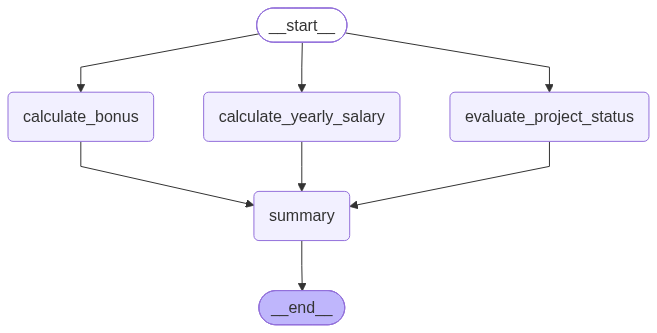

In [17]:
workflow

In [29]:
initial_state = EmployeeState(
    employee_name="John",
    monthly_salary=5000,
    working_days=22,
    completed_projects=4)

result = workflow.invoke(initial_state)

In [30]:
result 

{'employee_name': 'John',
 'monthly_salary': 5000,
 'working_days': 22,
 'completed_projects': 4,
 'yearly_salary': 60000,
 'bonus_amount': 2000.0,
 'project_status': 'Good',
 'summary': 'Employee John has a yearly salary of 60000, a bonus amount of 2000.0, and their project status is Good.'}